# Лабораторная работа №3. Использование библиотеки numpy

Выполняется основной вариант заданий (задачи 1 и 2).

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.linalg import solve

## Задача 1. Производство и потребление электроэнергии

### 1. Загрузка данных

Пропущенные значения в файлах обозначены как `--` или `ie`, при загрузке они превращаются в `nan`.

In [2]:
gen_file = 'global-electricity-generation.csv'
cons_file = 'global-electricity-consumption.csv'

countries = np.genfromtxt(gen_file, delimiter=',', skip_header=1, usecols=0,
                          dtype=str, encoding='utf-8-sig', autostrip=True)
years = np.genfromtxt(gen_file, delimiter=',', max_rows=1, encoding='utf-8-sig')[1:].astype(int)
generation = np.genfromtxt(gen_file, delimiter=',', skip_header=1, encoding='utf-8-sig')[:, 1:]
consumption = np.genfromtxt(cons_file, delimiter=',', skip_header=1, encoding='utf-8-sig')[:, 1:]

print('Стран:', countries.size)
print('Годы:', years[0], '-', years[-1])
print('Размер массивов:', generation.shape, consumption.shape)
print(countries[:5])

Стран: 217
Годы: 1992 - 2021
Размер массивов: (217, 30) (217, 30)
['Algeria' 'Angola' 'Benin' 'Botswana' 'Burkina Faso']


### 2. Среднее ежегодное производство и потребление за последние 5 лет

У некоторых стран за последние 5 лет нет ни одного значения. Для них среднее
не определено и остаётся `nan` (предупреждение `Mean of empty slice` при этом подавляем).

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gen_last5 = np.nanmean(generation[:, -5:], axis=1)
    cons_last5 = np.nanmean(consumption[:, -5:], axis=1)

print('Годы:', years[-5:])
print('Производство:', gen_last5[:5])
print('Потребление:', cons_last5[:5])
print('Нет данных о производстве:', countries[np.isnan(gen_last5)])
print('Нет данных о потреблении:', countries[np.isnan(cons_last5)])

Годы: [2017 2018 2019 2020 2021]
Производство: [74.11122599 14.3874744   0.23413146  2.61904963  1.68525657]
Потребление: [64.28035439 12.76531834  0.8581896   3.58826363  2.41878548]
Нет данных о производстве: ['Reunion' 'French Guiana' 'Guadeloupe' 'Martinique']
Нет данных о потреблении: []


### 3.1. Суммарное потребление электроэнергии за каждый год

In [4]:
total_cons = np.nansum(consumption, axis=0)
for year, value in zip(years, total_cons):
    print(year, round(value, 2))

1992 10569.02
1993 10854.56
1994 11104.65
1995 11476.48
1996 11805.87
1997 12122.03
1998 12419.81
1999 12685.75
2000 13230.25
2001 13486.49
2002 13938.78
2003 14455.56
2004 15128.1
2005 15725.98
2006 16438.21
2007 17205.12
2008 17477.47
2009 17435.69
2010 18748.16
2011 19438.82
2012 19918.25
2013 20573.1
2014 20981.24
2015 21400.02
2016 22022.69
2017 22716.21
2018 23530.92
2019 23915.66
2020 23959.68
2021 25336.71


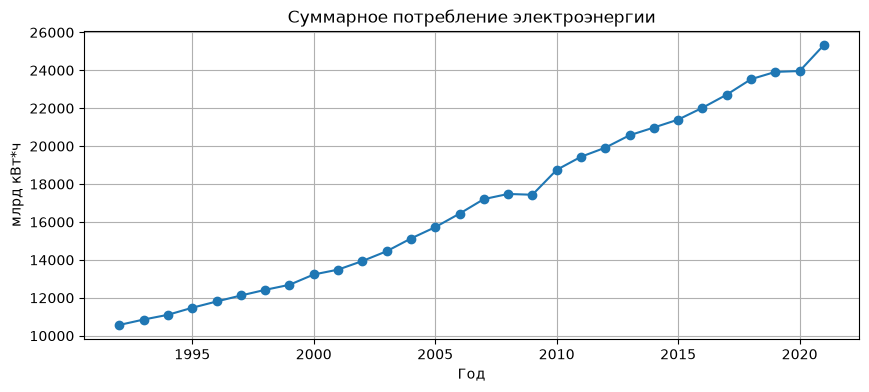

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(years, total_cons, marker='o')
plt.title('Суммарное потребление электроэнергии')
plt.xlabel('Год')
plt.ylabel('млрд кВт*ч')
plt.grid()
plt.show()

### 3.2. Максимальное производство одной страной за один год

In [6]:
max_gen = np.nanmax(generation)
row, col = np.unravel_index(np.nanargmax(generation), generation.shape)
print(f'{max_gen:.2f} млрд кВт*ч ({countries[row]}, {years[col]} год)')

8151.52 млрд кВт*ч (China, 2021 год)


### 3.3. Страны, производящие более 500 млрд кВт*ч в среднем за последние 5 лет

In [7]:
countries[gen_last5 > 500]

array(['Russia', 'France', 'Germany', 'China', 'India', 'Japan',
       'South Korea', 'Canada', 'United States', 'Brazil'], dtype='<U25')

### 3.4. 10% стран, которые потребляют больше всего электроэнергии

In [8]:
q90 = np.nanquantile(cons_last5, 0.9)
print(f'Квантиль 0.9: {q90:.2f}')
top = cons_last5 >= q90
order = np.argsort(-cons_last5[top])
for name, value in zip(countries[top][order], cons_last5[top][order]):
    print(f'{name}: {value:.2f}')

Квантиль 0.9: 198.31
China: 6846.21
United States: 3957.50
India: 1330.94
Russia: 946.68
Japan: 940.32
Canada: 547.32
Brazil: 539.93
South Korea: 539.51
Germany: 520.23
France: 445.22
Saudi Arabia: 324.52
United Kingdom: 303.54
Italy: 296.44
Mexico: 285.83
Iran: 282.51
Taiwan: 265.07
Turkiye: 263.49
Indonesia: 256.33
Spain: 240.37
Australia: 238.60
Vietnam: 206.12
South Africa: 200.65


### 3.5. Страны, увеличившие производство в 2021 году по сравнению с 1992 более чем в 10 раз

Страны с нулевым или отсутствующим значением в 1992 году не учитываются.

In [9]:
gen_1992 = generation[:, years == 1992].ravel()
gen_2021 = generation[:, years == 2021].ravel()
grew = (gen_1992 > 0) & (gen_2021 > 10 * gen_1992)
for name, a, b in zip(countries[grew], gen_1992[grew], gen_2021[grew]):
    print(f'{name}: {a:.3f} -> {b:.3f} (в {b / a:.1f} раз)')

Angola: 1.283 -> 16.429 (в 12.8 раз)
Benin: 0.023 -> 0.241 (в 10.5 раз)
Equatorial Guinea: 0.018 -> 1.418 (в 78.8 раз)
Ethiopia: 1.221 -> 14.678 (в 12.0 раз)
Mali: 0.271 -> 3.388 (в 12.5 раз)
Mauritania: 0.139 -> 1.876 (в 13.5 раз)
Mozambique: 0.408 -> 19.908 (в 48.8 раз)
Sudan: 1.590 -> 16.595 (в 10.4 раз)
Cambodia: 0.166 -> 8.694 (в 52.4 раз)
China: 716.040 -> 8151.518 (в 11.4 раз)
Laos: 0.898 -> 39.971 (в 44.5 раз)
Maldives: 0.028 -> 0.662 (в 23.6 раз)
Vietnam: 9.430 -> 243.768 (в 25.9 раз)
Turks and Caicos Islands: 0.026 -> 0.273 (в 10.5 раз)


### 3.6. Страны, потратившие за все годы больше 100 млрд кВт*ч и произведшие меньше, чем потратили

In [10]:
cons_total = np.nansum(consumption, axis=1)
gen_total = np.nansum(generation, axis=1)
mask = (cons_total > 100) & (gen_total < cons_total)
for name, c, g in zip(countries[mask], cons_total[mask], gen_total[mask]):
    print(f'{name}: потребление {c:.2f}, производство {g:.2f}')

Zimbabwe: потребление 260.62, производство 238.18
Belarus: потребление 922.33, производство 895.46
Moldova: потребление 202.82, производство 180.22
Belgium: потребление 2395.91, производство 2342.36
Croatia: потребление 418.57, производство 342.39
Finland: потребление 2356.64, производство 2069.42
Hungary: потребление 1066.96, производство 981.68
Italy: потребление 8576.57, производство 7879.03
Latvia: потребление 179.29, производство 146.66
Luxembourg: потребление 177.54, производство 38.27
Netherlands: потребление 3106.41, производство 2896.51
North Macedonia: потребление 186.88, производство 177.76
Hong Kong: потребление 1152.85, производство 998.42


### 3.7. Страна, потратившая больше всего электроэнергии в 2020 году

In [11]:
cons_2020 = consumption[:, years == 2020].ravel()
i = np.nanargmax(cons_2020)
print(f'{countries[i]}: {cons_2020[i]:.2f} млрд кВт*ч')

China: 7115.08 млрд кВт*ч


## Задача 2. Зависимость прибыли от скидки

### Загрузка данных

In [12]:
data = np.genfromtxt('data2.csv', delimiter=';', encoding='utf-8-sig')
x, y = data[:, 0], data[:, 1]
print('Точек:', x.size)
print('Скидка от', x.min(), 'до', x.max())

Точек: 26
Скидка от 0.0 до 5.0


Вспомогательные функции. Для полинома степени `k` по выбранным точкам строится СЛУ
с матрицей Вандермонда: в каждой строке `[x^k, ..., x, 1]`, правая часть — значения `y`.

In [13]:
def build_system(indices, degree):
    A = np.vander(x[indices], degree + 1)
    b = y[indices]
    return A, b


def poly_values(coefs, points):
    return np.polyval(coefs, points)


def rss(coefs):
    return np.sum((y - poly_values(coefs, x)) ** 2)


def fit(indices, degree):
    A, b = build_system(indices, degree)
    return solve(A, b)


def show(coefs, indices, title):
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, 'o-', label='Исходные данные')
    plt.plot(x, poly_values(coefs, x), label='Полином')
    plt.plot(x[indices], y[indices], 'rs', label='Опорные точки')
    plt.title(title)
    plt.xlabel('Скидка, %')
    plt.ylabel('Прибыль')
    plt.legend()
    plt.grid()
    plt.show()

### Полином 2-й степени

1–2. Выбираем 3 точки: начало, середину и конец диапазона, составляем и решаем СЛУ.

In [14]:
idx2 = np.array([0, x.size // 2, x.size - 1])
A2, b2 = build_system(idx2, 2)
print('Точки x:', x[idx2])
print('Матрица A:')
print(A2)
print('Правая часть b:', b2)

coefs2 = solve(A2, b2)
print('Коэффициенты a2, a1, a0:', coefs2)

Точки x: [0.  2.6 5. ]
Матрица A:
[[ 0.    0.    1.  ]
 [ 6.76  2.6   1.  ]
 [25.    5.    1.  ]]
Правая часть b: [-7.69796582 17.26743396 25.23920411]
Коэффициенты a2, a1, a0: [-1.25610119 12.86793993 -7.69796582]


3. Значения полинома в заданных точках

In [15]:
f2 = poly_values(coefs2, x)
f2

array([-7.69796582, -5.17462188, -2.75176604, -0.42939829,  1.79248136,
        3.91387292,  5.93477638,  7.85519175,  9.67511902, 11.3945582 ,
       13.01350928, 14.53197227, 15.94994716, 17.26743396, 18.48443266,
       19.60094327, 20.61696578, 21.5325002 , 22.34754652, 23.06210475,
       23.67617488, 24.18975691, 24.60285086, 24.9154567 , 25.12757445,
       25.23920411])

4. Графики

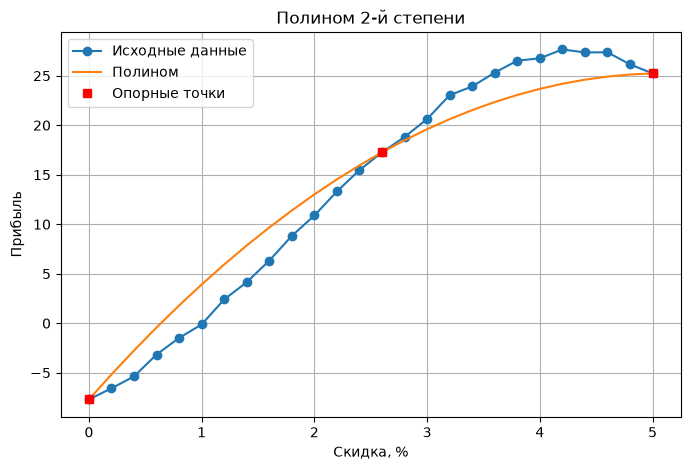

In [16]:
show(coefs2, idx2, 'Полином 2-й степени')

5. Квадратичное отклонение

In [17]:
rss2 = rss(coefs2)
print(f'RSS = {rss2:.4f}')

RSS = 163.3635


### Полином 3-й степени

6. Те же шаги для 4 точек, равномерно расположенных по диапазону.

Точки x: [0.  1.6 3.4 5. ]
Матрица A:
[[  0.      0.      0.      1.   ]
 [  4.096   2.56    1.6     1.   ]
 [ 39.304  11.56    3.4     1.   ]
 [125.     25.      5.      1.   ]]
Правая часть b: [-7.69796582  6.32790239 23.92053257 25.23920411]
Коэффициенты a3, a2, a1, a0: [-0.58570762  3.22486627  5.10579311 -7.69796582]
Значения полинома: [-7.69796582 -6.55249821 -5.17715526 -3.60005094 -1.84929922  0.04698594
  2.06069057  4.16370071  6.32790239  8.52518165 10.72742452 12.90651703
 15.03434523 17.08279513 19.02375278 20.82910422 22.47073547 23.92053257
 25.15038156 26.13216846 26.83777932 27.23910016 27.30801703 27.01641596
 26.33618297 25.23920411]
RSS = 1.9542


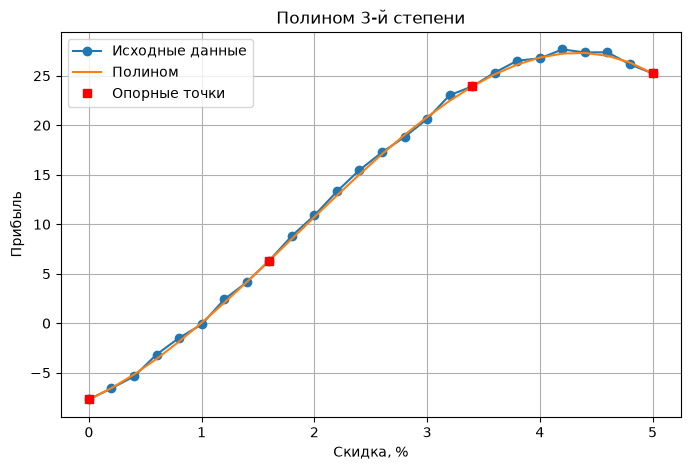

In [18]:
idx3 = np.round(np.linspace(0, x.size - 1, 4)).astype(int)
A3, b3 = build_system(idx3, 3)
print('Точки x:', x[idx3])
print('Матрица A:')
print(A3)
print('Правая часть b:', b3)

coefs3 = solve(A3, b3)
print('Коэффициенты a3, a2, a1, a0:', coefs3)

f3 = poly_values(coefs3, x)
print('Значения полинома:', f3)

rss3 = rss(coefs3)
print(f'RSS = {rss3:.4f}')
show(coefs3, idx3, 'Полином 3-й степени')

### 7. Эксперимент с выбором точек

Перебираем все возможные наборы из 3 и 4 точек и ищем те, при которых RSS минимально.

2-я степень: точки x = [0.6 2.4 4.6], RSS = 63.4108
3-я степень: точки x = [0.  2.6 3.6 5. ], RSS = 1.4056


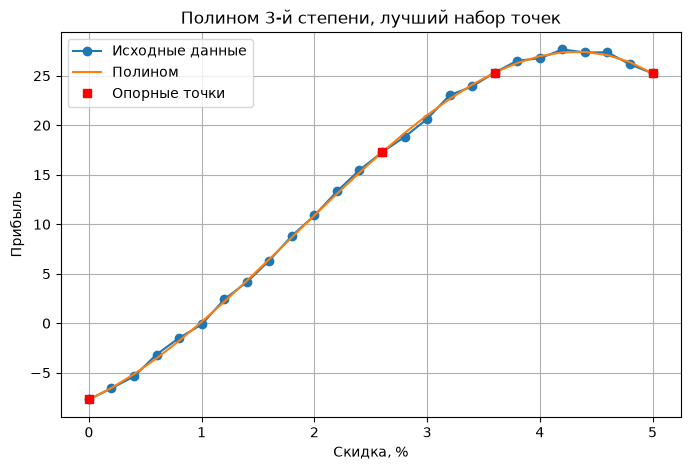

In [19]:
def best_points(degree):
    best = None
    for indices in combinations(range(x.size), degree + 1):
        indices = np.array(indices)
        coefs = fit(indices, degree)
        value = rss(coefs)
        if best is None or value < best[0]:
            best = (value, indices, coefs)
    return best


rss2_best, idx2_best, coefs2_best = best_points(2)
rss3_best, idx3_best, coefs3_best = best_points(3)

print(f'2-я степень: точки x = {x[idx2_best]}, RSS = {rss2_best:.4f}')
print(f'3-я степень: точки x = {x[idx3_best]}, RSS = {rss3_best:.4f}')
show(coefs3_best, idx3_best, 'Полином 3-й степени, лучший набор точек')

### 8. Выбор лучшего варианта и прогноз

In [20]:
variants = {
    '2-я степень, равномерные точки': (rss2, coefs2),
    '3-я степень, равномерные точки': (rss3, coefs3),
    '2-я степень, лучшие точки': (rss2_best, coefs2_best),
    '3-я степень, лучшие точки': (rss3_best, coefs3_best),
}
for name, (value, _) in variants.items():
    print(f'{name}: RSS = {value:.4f}')

best_name = min(variants, key=lambda name: variants[name][0])
best_coefs = variants[best_name][1]
print('\nЛучший вариант:', best_name)

for discount in (6, 8):
    print(f'Скидка {discount}%: ожидаемая прибыль {poly_values(best_coefs, discount):.4f}')

2-я степень, равномерные точки: RSS = 163.3635
3-я степень, равномерные точки: RSS = 1.9542
2-я степень, лучшие точки: RSS = 63.4108
3-я степень, лучшие точки: RSS = 1.4056

Лучший вариант: 3-я степень, лучшие точки
Скидка 6%: ожидаемая прибыль 12.2499
Скидка 8%: ожидаемая прибыль -61.6352


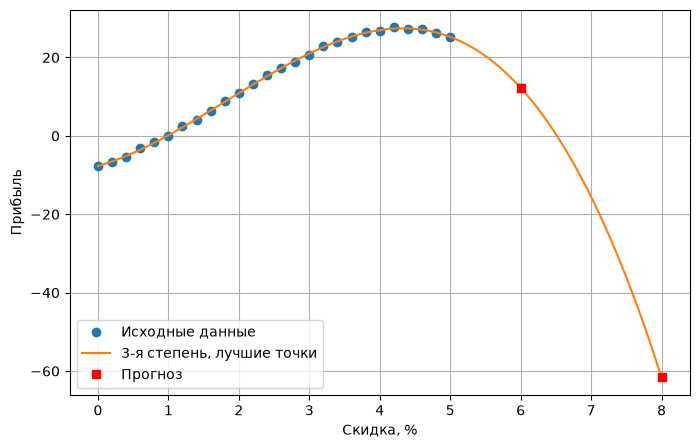

In [21]:
xs = np.linspace(0, 8, 200)
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Исходные данные')
plt.plot(xs, poly_values(best_coefs, xs), label=best_name)
plt.plot([6, 8], poly_values(best_coefs, np.array([6, 8])), 'rs', label='Прогноз')
plt.xlabel('Скидка, %')
plt.ylabel('Прибыль')
plt.legend()
plt.grid()
plt.show()